# Lab 4 — Hypothesis & Sampling

**Day 01 · Data Science Introduction · Cisco AI/ML Training**

---

## Goals

1. Distinguish **population** vs **sample** statistics on the same CSV.
2. Frame a simple **hypothesis** (H₀ / H₁) about team growth.
3. Draw random samples and observe **sampling variation**.
4. Compute **proportions** (growth rate) overall and by region.
5. Build intuition for **confidence** via repeated samples (bootstrap preview).

> **Quick check:** pop mean ≈ **1002.76** · sample(n=10) mean ≈ **810.4** · growth **0.58** · West team growth **0.49**




## Why this matters

You rarely measure every customer or transaction. Sampling error is why A/B tests and loan default models need careful experimental design (Days 3–4).

## Hypothesis framing

| | Statement |
|--|----------|
| **H₀** | Most teams did **not** improve Q2 vs Q1 (growth rate ≤ 50%) |
| **H₁** | Majority of teams improved (growth rate > 50%) |

We observe **15/20 = 75%** with Q2 > Q1 — does that support H₁ in plain language?

---

## 1. Population statistics

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif GH_ROOT.name == "01-data-science-introduction":
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "data" / "team-sales" / "team_sales.csv").is_file():
            GH_ROOT = parent
            break

TEAM_SALES_CSV = GH_ROOT / "data" / "team-sales" / "team_sales.csv"

import json

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
LAB_PROFILE = json.loads(
    (GH_ROOT / "data" / "team-sales" / "lab_profile.json").read_text(encoding="utf-8")
)
OUTLIER_TEAM = LAB_PROFILE["outlier_team_id"]
VOL_REGION = LAB_PROFILE["compare_region_volume"]
GROWTH_REGION = LAB_PROFILE["compare_region_growth"]
df = pd.read_csv(TEAM_SALES_CSV)

# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())

Loaded 100 rows x 11 columns
dtypes: {'team': dtype('O'), 'team_name': dtype('O'), 'region': dtype('O'), 'state': dtype('O'), 'product_line': dtype('O'), 'sub_category': dtype('O'), 'segment': dtype('O'), 'q1_sales': dtype('int64'), 'q2_sales': dtype('int64'), 'q1_units': dtype('int64'), 'q2_units': dtype('int64')}


**Step 4** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [4]:
population_mean = df["q2_sales"].mean()
population_median = df["q2_sales"].median()
print(f"Population size N = {len(df)}")
print(f"Population mean Q2:   {population_mean:.2f}")
print(f"Population median Q2: {population_median:.2f}")

Population size N = 100
Population mean Q2:   1002.76
Population median Q2: 705.00


### 1b. Population growth flag

In [5]:
df["grew"] = df["q2_sales"] > df["q1_sales"]
growth_count = int(df["grew"].sum())
growth_rate = df["grew"].mean()
print(f"Teams with Q2 > Q1: {growth_count} / {len(df)}")
print(f"Population growth rate: {growth_rate:.2f}")


Teams with Q2 > Q1: 58 / 100
Population growth rate: 0.58


---

## 2. Random sample (n = 10, random_state = 42)

In [6]:
sample = df.sample(n=10, random_state=42)
sample_mean = sample["q2_sales"].mean()
diff = abs(population_mean - sample_mean)

print("Sample teams:")
display(sample[["team", "region", "q2_sales"]].sort_values("q2_sales"))
print(f"\nSample mean:      {sample_mean:.2f}")
print(f"Population mean:  {population_mean:.2f}")
print(f"Difference:       {diff:.2f}")
print("\nOne small sample can mislead — that is sampling error.")


Sample teams:


,team,region,q2_sales
10,TS011,Central,307
45,TS046,East,315
70,TS071,West,331
44,TS045,East,437
80,TS081,West,519
53,TS054,East,750
39,TS040,East,1096
0,TS001,Central,1252
22,TS023,Central,1455
83,TS084,West,1642



Sample mean:      810.40
Population mean:  1002.76
Difference:       192.36

One small sample can mislead — that is sampling error.


### 2b. Sample growth rate vs population

In [7]:
sample_growth = sample["grew"].mean()
print(f"Sample growth rate (n=10): {sample_growth:.2f}")
print(f"Population growth rate:    {growth_rate:.2f}")


Sample growth rate (n=10): 0.50
Population growth rate:    0.58


---

## 3. Regional proportions — all four regions

In [8]:
regional = (
    df.groupby("region")["grew"]
    .agg(growth_count="sum", teams="count")
    .assign(growth_rate=lambda x: x["growth_count"] / x["teams"])
    .round(3)
)
display(regional.sort_values("growth_rate", ascending=False))

volume_leader_growth = regional.loc["West", "growth_rate"]
print(f"West growth rate: {volume_leader_growth:.2f}")


,growth_count,teams,growth_rate
region,,,
South,4,5,0.800
Central,16,24,0.667
East,19,32,0.594
West,19,39,0.487


West growth rate: 0.49


---

## 4. Sampling distribution — 20 draws

20 sample means — min: 563.1, max: 1507.7
Mean of sample means: 1031.30
Spread (std):         278.36


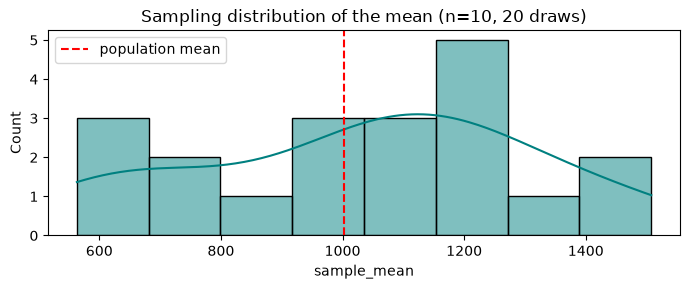

In [9]:
sample_means = [df.sample(n=10, random_state=i)["q2_sales"].mean() for i in range(20)]
means_series = pd.Series(sample_means, name="sample_mean")

print(f"20 sample means — min: {means_series.min():.1f}, max: {means_series.max():.1f}")
print(f"Mean of sample means: {means_series.mean():.2f}")
print(f"Spread (std):         {means_series.std(ddof=1):.2f}")

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(means_series, bins=8, kde=True, ax=ax, color="teal")
ax.axvline(population_mean, color="red", linestyle="--", label="population mean")
ax.set_title("Sampling distribution of the mean (n=10, 20 draws)")
ax.legend()
plt.tight_layout()
plt.show()


### 4b. Ten draws side-by-side (extension)

In [10]:
ten_draws = pd.DataFrame({
    f"draw_{i}": [df.sample(n=10, random_state=i)["q2_sales"].mean()] for i in range(10)
}).T
ten_draws.columns = ["sample_mean"]
display(ten_draws.round(2))
print(f"Range across 10 draws: {ten_draws['sample_mean'].min():.2f} – {ten_draws['sample_mean'].max():.2f}")


,sample_mean
draw_0,700.5
draw_1,979.8
draw_2,1386.5
draw_3,1411.9
draw_4,682.2
draw_5,1173.1
draw_6,563.1
draw_7,1507.7
draw_8,604.1
draw_9,642.8


Range across 10 draws: 563.10 – 1507.70


### 4c. Excel parallel — `RAND` / `INDEX` sampling

In Excel you can simulate sampling with helper columns:

1. `=RAND()` in a helper column to shuffle rows
2. Sort ascending on helper → take top 10 rows
3. `=AVERAGE()` on those 10 Q2 values

Re-sort (F9 recalc) and watch the average move — same lesson as the Python loop above.

### 4d. Stratified peek — sample 2 teams per region

In [11]:
stratified = df.groupby("region", group_keys=False).apply(
    lambda g: g.sample(n=2, random_state=42)
)
print(f"Stratified sample size: {len(stratified)}")
display(stratified[["team", "region", "q2_sales"]].sort_values("region"))
print(f"Stratified mean Q2: {stratified['q2_sales'].mean():.2f}")
print(f"Simple random mean: {sample_mean:.2f}")


Stratified sample size: 8


C:\Users\PC\AppData\Local\Temp\ipykernel_10340\3557460622.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified = df.groupby("region", group_keys=False).apply(


,team,region,q2_sales
8,TS009,Central,98
16,TS017,Central,344
53,TS054,East,750
39,TS040,East,1096
57,TS058,South,1268
60,TS061,South,504
94,TS095,West,849
97,TS098,West,212


Stratified mean Q2: 640.12
Simple random mean: 810.40


### 4e. Outlier impact on sample means (50 draws)

In [12]:
draw_means = pd.Series(
    [df.sample(n=10, random_state=i)["q2_sales"].mean() for i in range(50)]
)
draws_with_13 = [
    "TS029" in df.sample(n=10, random_state=i)["team"].values for i in range(50)
]
print(f"50 random samples (n=10): mean range {draw_means.min():.1f} – {draw_means.max():.1f}")
print(f"TS029 appeared in {sum(draws_with_13)}/50 samples")
print(f"When TS029 included, avg sample mean: {draw_means[draws_with_13].mean():.1f}")
print(f"When TS029 excluded:                  {draw_means[[not x for x in draws_with_13]].mean():.1f}")


50 random samples (n=10): mean range 563.1 – 2094.0
TS029 appeared in 5/50 samples
When TS029 included, avg sample mean: 1277.4
When TS029 excluded:                  993.0


### 4f. Proportion practice — declining teams

In [13]:
decline_rate = 1 - growth_rate
decliners = df.loc[~df["grew"], ["team", "region", "q1_sales", "q2_sales"]]
print(f"Decline rate: {decline_rate:.2f}")
display(decliners)


Decline rate: 0.42


,team,region,q1_sales,q2_sales
4,TS005,Central,560,367
7,TS008,Central,481,109
8,TS009,Central,398,98
9,TS010,Central,1352,615
10,TS011,Central,933,307
11,TS012,Central,601,191
19,TS020,Central,956,200
22,TS023,Central,1987,1455
26,TS027,East,450,101
29,TS030,East,1240,244


### 4g. Write-up worksheet (fill in your notebook or paper)

| Question | Your answer |
|----------|-------------|
| Population N | |
| Sample n (main demo) | |
| H₁ in one sentence | |
| Does 75% growth support H₁? | |
| Why not conclude causation? | |

---

## 5. Checkpoint

In [14]:
assert len(df) == LAB_PROFILE["rows"]
assert abs(population_mean - LAB_PROFILE["q2_mean"]) < 0.01
assert len(sample) == 10
assert abs(sample_mean - LAB_PROFILE["sample_n10_mean_rs42"]) < 0.01
assert growth_count == LAB_PROFILE["growth_teams_count"]
assert abs(growth_rate - LAB_PROFILE["growth_rate_fraction"]) < 0.001
assert abs(volume_leader_growth - LAB_PROFILE["volume_leader_team_growth_rate"]) < 0.001
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection questions

1. Why is the sample mean (810.4) below the population mean (1002.76) for `random_state=42`?
2. If West's team-level growth rate is about 49%, can we say West is "better" than Central (67% of teams grew)? What is missing?
3. How would larger sample size (n=15) change the histogram spread?